In [ ]:
!pip install gseapy

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as ss
import scipy.cluster.hierarchy as sch
import statsmodels.stats.multitest as ssm
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp
import time

from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [ ]:
cohort = "synergy"  # "synergy" or "immu"

expr_file = f"{cohort}_expression_filtered.tsv"
sigma_file = f"{cohort}_signatures_filtered.tsv"

prefix = f"{cohort}_"

In [ ]:
brca_expr_df = pd.read_csv(expr_file, sep="\t", index_col=0)
sigma_count_df = pd.read_csv(sigma_file, sep="\t", index_col=0)

brca_expr_genes = brca_expr_df.index

print(brca_expr_df.shape)
print(sigma_count_df.shape)
print(brca_expr_df.columns.equals(sigma_count_df.columns))

(38286, 100)
(17, 100)
True


# Compute correlation

In [ ]:
def comp_corr(x_col, y_col, nan_th=30):
    """
    compute correlation of x_col  and y_col
    x_col: expression
    y_col: sig count
    nan_th: allow some NaN as long as valid elements > nan_th
    """
    if (~x_col.isnull()).sum() >= nan_th:
        corr, pv = ss.spearmanr(x_col, y_col, nan_policy='omit')
    else:
        corr, pv = 0, 1 # if not enough samples
    return corr, pv

def comp_corr_all(x_df, y_df):
    """
    spearman correlation between gene expression and signatures

    :param x_df: gene expression DataFrame : samples (rows) X genes (columns)
    :param y_df: signature DataFrame: samples (rows) X signatures (columns)
    :return: corr_df (x*y)
    """
    # compute correlation
    corr_df = pd.DataFrame(index=x_df.columns, columns=y_df.columns)
    pv_df = pd.DataFrame(index=x_df.columns, columns=y_df.columns)
    for j in range(y_df.shape[1]):
        print(y_df.columns[j])
        corr_results = [comp_corr(x_df.iloc[:,i], y_df.iloc[:, j]) for i in range(x_df.shape[1])]
        # print(corr_results)
        corr_list, pv_list = tuple(zip(*corr_results))
        corr_df.iloc[:,j] = corr_list
        pv_df.iloc[:,j] = pv_list
    return corr_df, pv_df

In [ ]:
print(brca_expr_df.T.shape)

(100, 38286)


In [ ]:
print(sigma_count_df.T.shape)

(100, 17)


In [ ]:
sigs_of_interest = ["SBS1", "SBS2", "SBS3", "SBS5", "SBS6", "SBS13", "SBS15", "SBS32", "SBS39", "SBS84", "SBS87"]

corr_df, pv_df = comp_corr_all(brca_expr_df.T, sigma_count_df.T[sigs_of_interest])

corr_df.index = brca_expr_genes
pv_df.index = brca_expr_genes

SBS1
SBS2
SBS3
SBS5
SBS6
SBS13
SBS15
SBS32
SBS39
SBS84
SBS87


In [ ]:
corr_df.to_csv(f"{prefix}corr_expr_sigma_count.tsv", sep="\t")
pv_df.to_csv(f"{prefix}corr_pv_expr_sigma_count.tsv", sep="\t")

# Correlation analysis




In [ ]:
corr_count = corr_df.copy()
pv_count = pv_df.copy()

In [ ]:
print(list(corr_count.columns))

['SBS1', 'SBS2', 'SBS3', 'SBS5', 'SBS6', 'SBS13', 'SBS15', 'SBS32', 'SBS39', 'SBS84', 'SBS87']


In [ ]:
# select genes based on pvalues and correlation
# threshold for correlation coefs and p-values

# we filter for genes with significant correlation with at least one signature
corr_th = 0.3
#fdr_th = 0.005
fdr_th = 0.3

sig_corr_dic = {}
sig_corr_genes = set([])

sigs = list(corr_count.columns)

for sig in sigs:
    print(sig)
    rej, pvc, a, b = ssm.multipletests(pv_count[sig], fdr_th, method="fdr_bh")
    sig_corr = pv_count.index[rej & ((corr_count[sig] >= corr_th)|(corr_count[sig] <= -corr_th))]
    print(len(sig_corr))
    if len(sig_corr) == 0:
        continue
    sig_corr_dic[sig] = sig_corr
    sig_corr_genes = sig_corr_genes.union(sig_corr)

print("\nTotal:", len(sig_corr_genes))

SBS1
132
SBS2
694
SBS3
120
SBS5
0
SBS6
558
SBS13
4
SBS15
10
SBS32
3
SBS39
22
SBS84
45
SBS87
2

Total: 1550


In [ ]:
genes_of_interest = sig_corr_genes

def create_corr_dic(corr_df, genes_of_interest):
    corr_subset = corr_df[corr_df.index.isin(genes_of_interest)]
    return corr_subset

corr_count_selected = create_corr_dic(corr_count, genes_of_interest)

print(corr_count_selected)

               SBS1      SBS2      SBS3      SBS5      SBS6     SBS13  \
Name                                                                    
NFYA      -0.083821 -0.313494  0.175551 -0.063427  0.072483 -0.262597   
LASP1      0.130678  0.304442  0.093319 -0.035683 -0.212779  0.146395   
CFLAR      0.251368  0.219403  0.050906 -0.064231  -0.31723    0.1173   
NDUFAF7   -0.120876 -0.312429  0.131601  0.032785  0.141535 -0.229925   
VPS50      0.008546  0.111586 -0.348349  0.061146 -0.001557  0.120248   
...             ...       ...       ...       ...       ...       ...   
MTND6P35  -0.022717  -0.00913 -0.005061  0.088014  0.323302  0.029642   
SSU72L5   -0.094144 -0.210221 -0.060506  0.063091  0.433481 -0.121019   
LINC01226  0.073552  0.429211 -0.064889  0.038978  -0.09112  0.316149   
LINC00842 -0.170465  -0.30463   0.14774 -0.140732 -0.008112 -0.304553   
LINC03114  -0.23736 -0.183504  0.000464  0.003419  0.102588 -0.164006   

              SBS15     SBS32     SBS39     SBS84 

In [ ]:
matrix_to_cluster = corr_count_selected
subset_genes = list(corr_count.index)

denom = 10
step = 5

In [ ]:
labels_all = []

# Fill NaN values with 0 before clustering
#matrix_to_cluster = matrix_to_cluster.fillna(0)

for ri in range(100):
    if ri%10 == 0:
        print(ri)
    clusterer_ri = MiniBatchKMeans(n_clusters=(int(ri/denom)+1)*step, random_state=ri)
    labels = clusterer_ri.fit_predict(matrix_to_cluster)
    labels_all.append(labels)

labels_df = pd.DataFrame(labels_all, columns=matrix_to_cluster.index)


0
10
20
30
40
50
60
70
80
90


In [ ]:
# find consensus score for each
def count_consensus(df, label):
    return (df == label).astype(int).sum(1)

consensus_df = pd.DataFrame()
labels_T = labels_df.T

# i added this:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=pd.errors.PerformanceWarning)

    for i in range(labels_df.shape[1]):
        if (i%1000==0): # print progress
            print(i)
        consensus_df[i] = count_consensus(labels_T, labels_T.iloc[i,:])

consensus_df.columns=consensus_df.index
consensus_df.to_csv(f"{prefix}corr_consensus.tsv", sep="\t")

0
1000


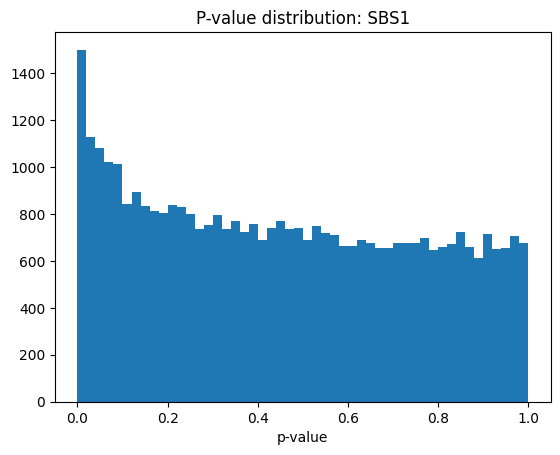

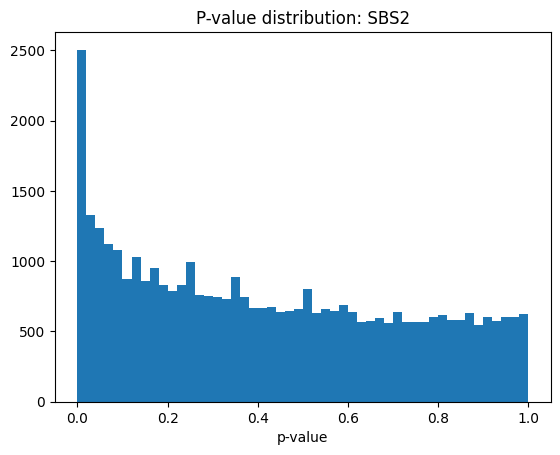

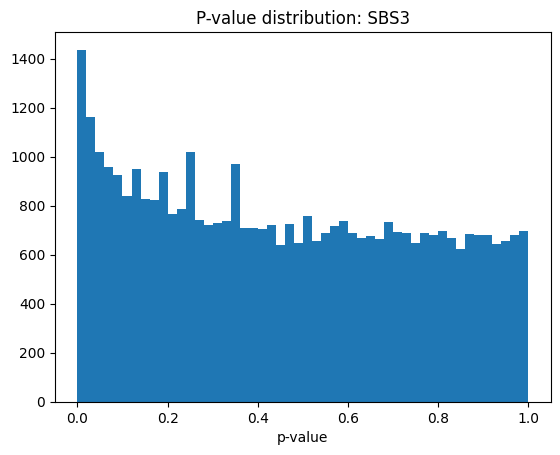

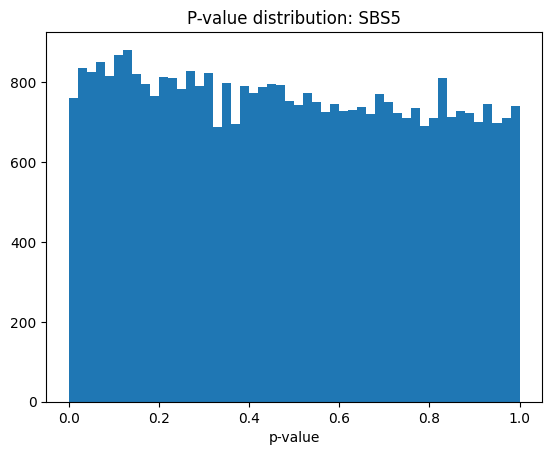

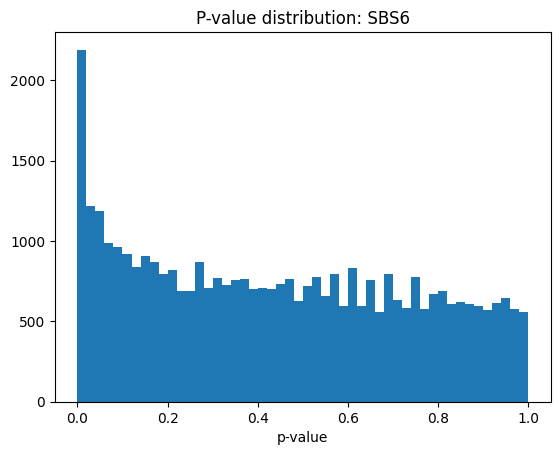

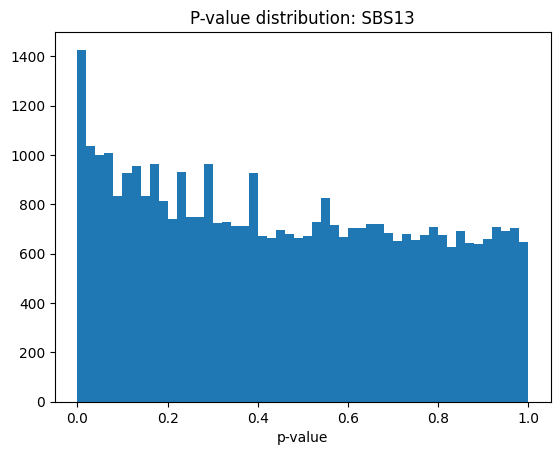

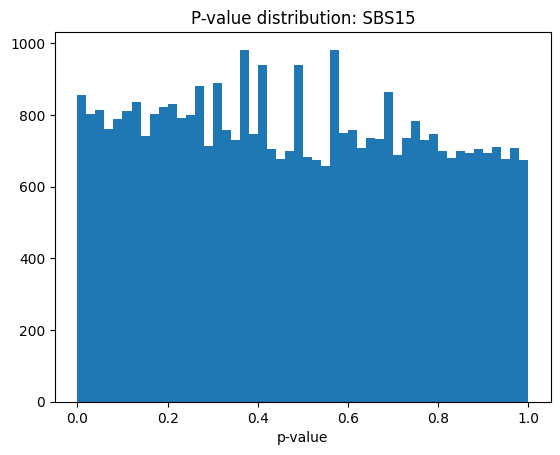

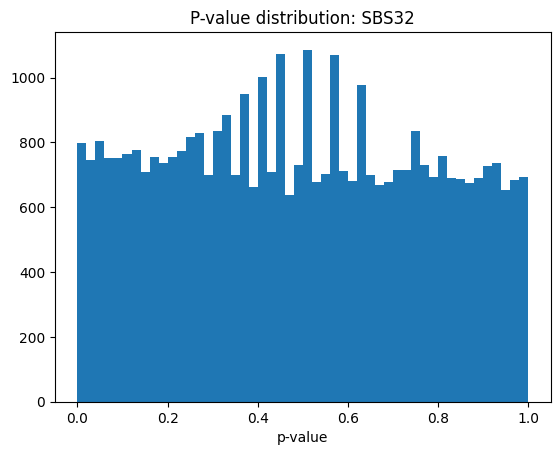

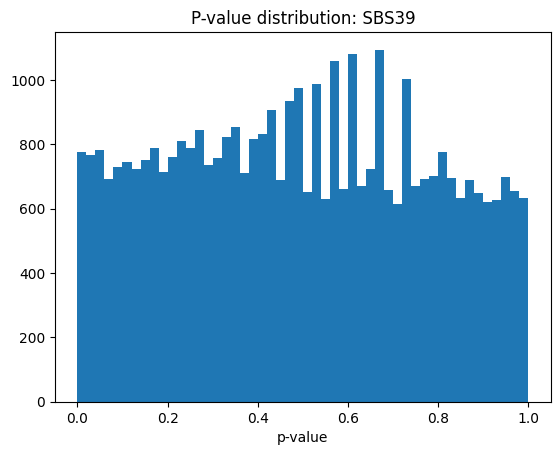

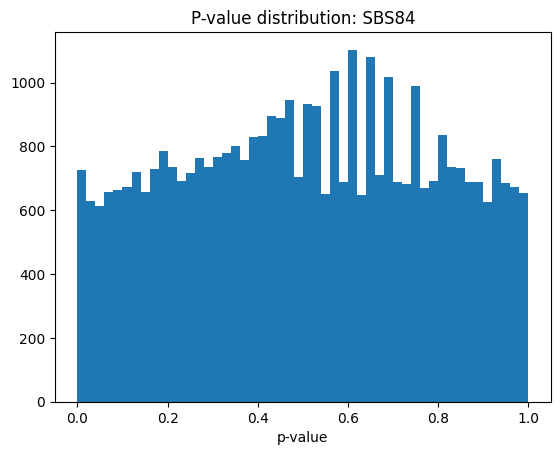

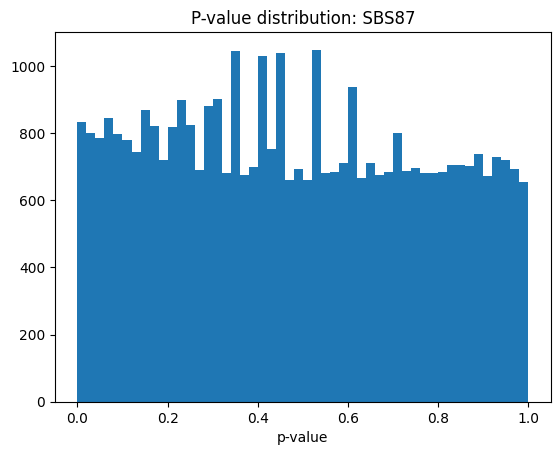

In [ ]:
for sig in sigs:
    plt.figure()
    plt.hist(pv_count[sig], bins=50)
    plt.title(f'P-value distribution: {sig}')
    plt.xlabel('p-value')
    plt.show()

In [ ]:
# hierarchical clustering

#consensus_mat = consensus_df.as_matrix() # no longer works
consensus_mat = consensus_df.to_numpy()
link_matrix = sch.linkage(consensus_mat, method="complete", metric="cosine")
# cluster_id_df = pd.DataFrame(index=matrix_to_cluster.index)
# nrange = range(7, 8)
# for n_clusters in nrange:
#     print(n_clusters)
#     th = [x[2] for x in link_matrix][-n_clusters]
#     labels = sch.fcluster(link_matrix, th, criterion='distance')
#     cluster_id_df["k="+str(n_clusters)] = labels

In [ ]:
silhouette_scores = {}

for k in range(2, 11):
    th = [x[2] for x in link_matrix][-k]
    labels = sch.fcluster(link_matrix, th, criterion="distance")

    score = silhouette_score(consensus_mat, labels, metric="cosine")
    silhouette_scores[k] = score

    print(f"k={k}: {score:.3f}")

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.xticks(range(2, 11))
plt.tight_layout()
plt.show()

best_k = max(silhouette_scores, key=silhouette_scores.get)

print("Best k:", best_k)
print("Silhouette score:", silhouette_scores[best_k])

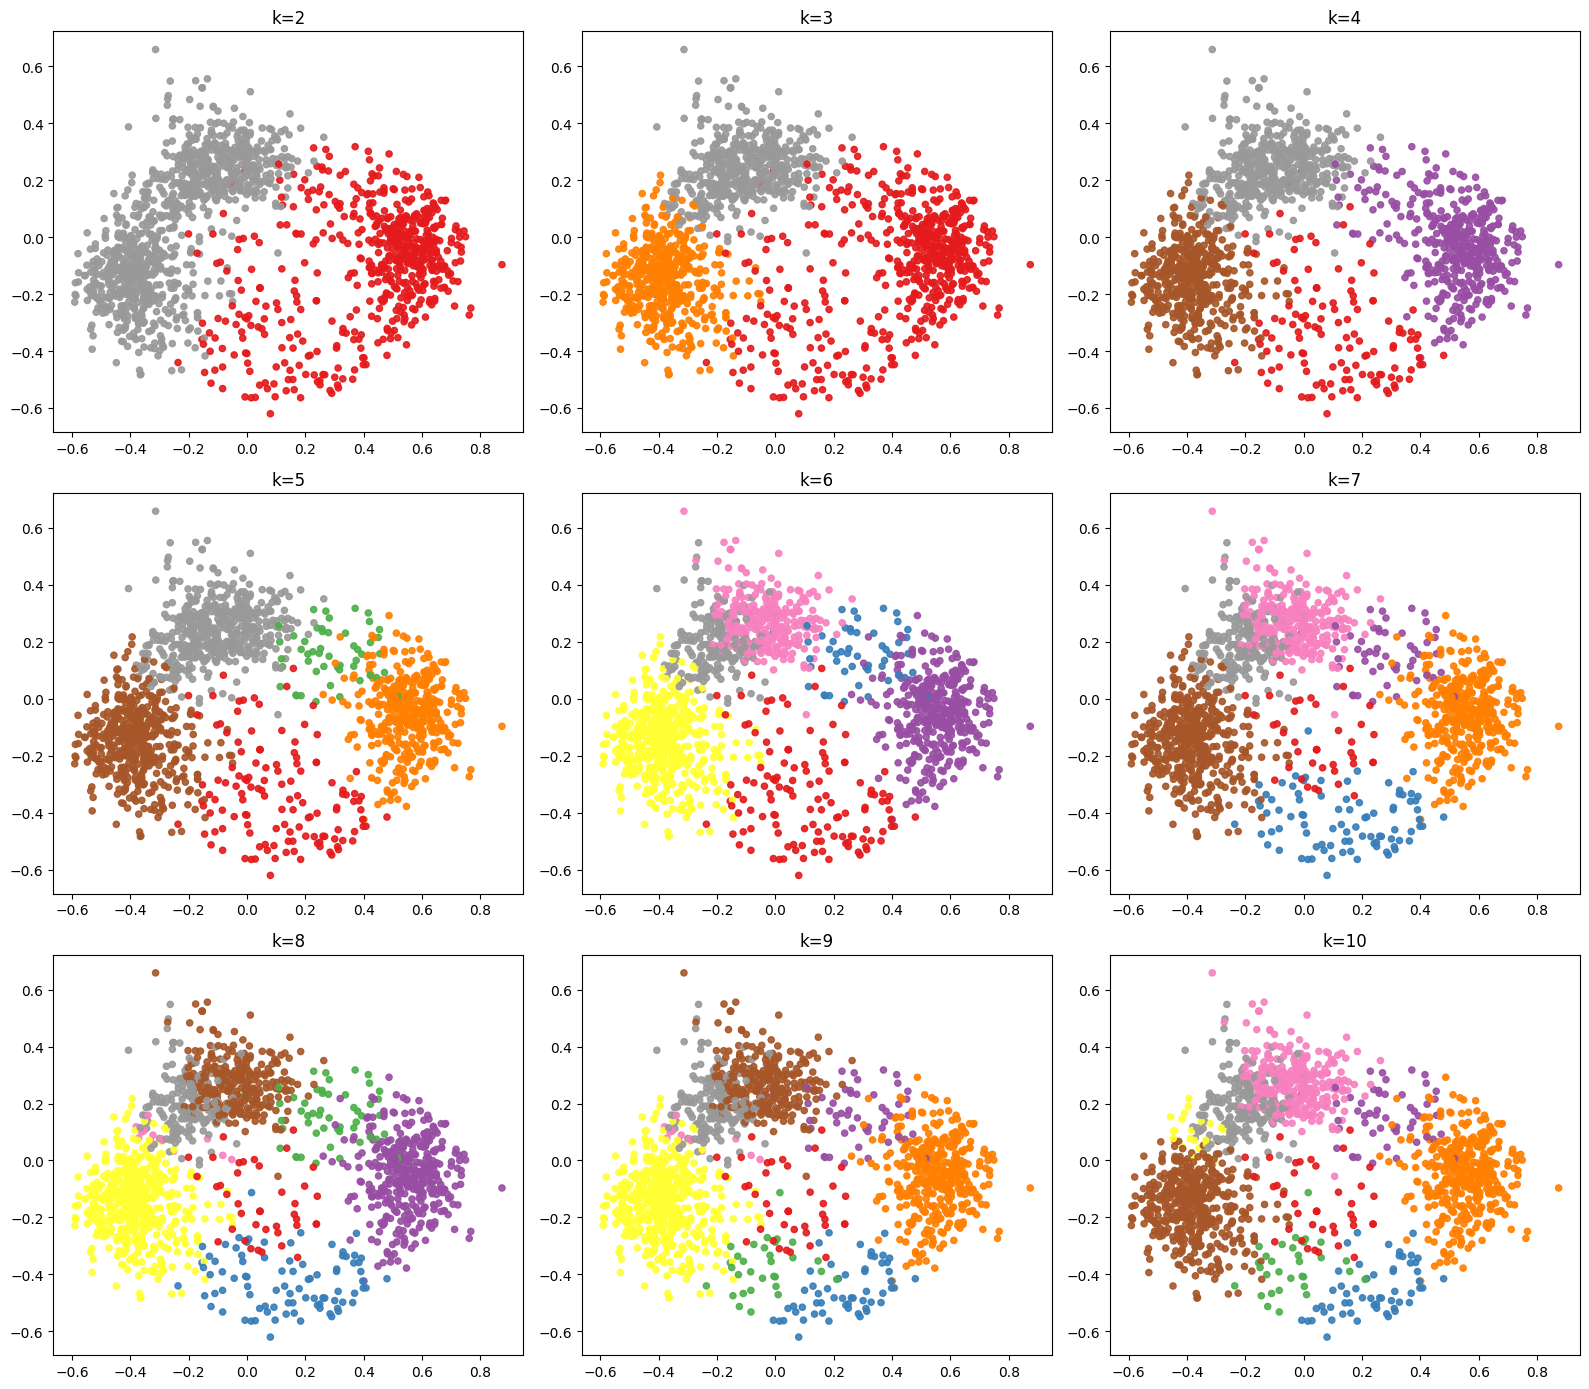

In [ ]:
pca = PCA(n_components=2)
coords = pca.fit_transform(matrix_to_cluster)

fig, axes = plt.subplots(3, 3, figsize=(16, 14))

for ax, k in zip(axes.flatten(), range(2, 11)):
    th = [x[2] for x in link_matrix][-k]
    labels = sch.fcluster(link_matrix, th, criterion="distance")

    ax.scatter(coords[:, 0], coords[:, 1], c=labels, cmap="Set1", s=20, alpha=0.9)
    ax.set_title(f"k={k}")

plt.tight_layout()
plt.show()

In [ ]:
final_k = best_k

th = [x[2] for x in link_matrix][-final_k]
labels = sch.fcluster(link_matrix, th, criterion="distance")

cluster_id_df = pd.DataFrame(index=matrix_to_cluster.index)
cluster_id_df[f"k={final_k}"] = labels

cluster_id_df.to_csv(f"{prefix}cluster_id_k{final_k}.tsv", sep="\t")

# Enrichment analysis

In [ ]:
clusters = cluster_id_df.reset_index()
clusters.columns = ["Gene", "Cluster"]

clusters["Gene"] = clusters["Gene"].astype(str).str.strip()

print("Cluster sizes:")
print(clusters["Cluster"].value_counts().sort_index())

display(clusters.head())

Cluster sizes:
Cluster
1    129
2     52
3    375
4    479
5    515
Name: count, dtype: int64


,Gene,Cluster
0,NFYA,4
1,LASP1,3
2,CFLAR,3
3,NDUFAF7,4
4,VPS50,2


Merged table shape:
(1550, 13)


,Gene,Cluster,SBS1,SBS2,SBS3,SBS5,SBS6,SBS13,SBS15,SBS32,SBS39,SBS84,SBS87
0,NFYA,4,-0.083821,-0.313494,0.175551,-0.063427,0.072483,-0.262597,-0.032816,0.009233,0.144514,-0.013887,0.030758
1,LASP1,3,0.130678,0.304442,0.093319,-0.035683,-0.212779,0.146395,-0.054481,-0.214415,-0.121626,-0.010645,-0.110552
2,CFLAR,3,0.251368,0.219403,0.050906,-0.064231,-0.317230,0.117300,-0.103282,0.013982,-0.063036,0.001017,-0.141714
3,NDUFAF7,4,-0.120876,-0.312429,0.131601,0.032785,0.141535,-0.229925,0.055794,0.033542,0.071696,0.111474,0.084248
4,VPS50,2,0.008546,0.111586,-0.348349,0.061146,-0.001557,0.120248,-0.083965,0.045541,0.045630,-0.068162,-0.056647


,SBS1,SBS2,SBS3,SBS5,SBS6,SBS13,SBS15,SBS32,SBS39,SBS84,SBS87
Cluster,,,,,,,,,,,
1,0.032358,0.009375,0.140279,-0.064275,-0.134674,0.000301,0.015486,-0.076295,-0.021313,0.201185,-0.052802
2,0.057463,0.095454,-0.354057,0.096926,0.044585,0.035193,-0.073835,0.110184,-0.038933,-0.020584,-0.001155
3,0.172318,0.317920,-0.092893,0.068876,-0.059057,0.230366,-0.048450,0.000908,-0.086276,-0.025416,-0.094702
4,-0.184067,-0.296973,0.122523,-0.064398,0.077855,-0.215399,0.086579,-0.009801,0.099106,0.000468,0.069661
5,-0.094965,-0.073013,-0.063462,0.046212,0.372205,-0.066039,-0.023347,0.046140,0.036500,-0.015333,-0.016814


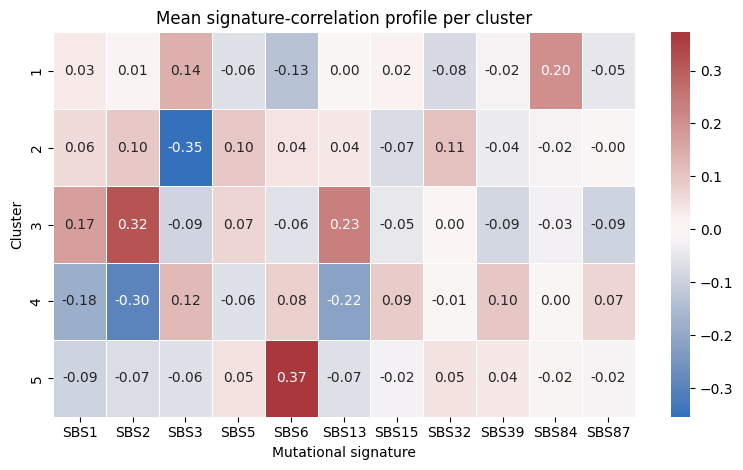

In [ ]:
# CHARACTERIZE CLUSTERS BY SIGNATURE-CORRELATION PROFILES
corr = corr_count.copy()
corr = corr_count.astype(float)
corr_reset = corr.reset_index()
corr_reset = corr_reset.rename(columns={corr_reset.columns[0]: "Gene"})

merged = clusters.merge(corr_reset, on="Gene", how="inner")

print("Merged table shape:")
print(merged.shape)

display(merged.head())

signature_cols = [col for col in merged.columns if col not in ["Gene", "Cluster"]]
cluster_means = merged.groupby("Cluster")[signature_cols].mean()

display(cluster_means)

plt.figure(figsize=(8, 4.8))
sns.heatmap(cluster_means, cmap="vlag", center=0, annot=True, fmt=".2f", linewidths=0.5)

plt.title("Mean signature-correlation profile per cluster")
plt.xlabel("Mutational signature")
plt.ylabel("Cluster")
plt.tight_layout()
plt.savefig(f"{prefix}cluster_mean_correlation_heatmap_k{final_k}.png", dpi=300)
plt.show()

In [ ]:
background_genes = corr.index.astype(str).str.strip().unique().tolist()

print("Background genes:", len(background_genes))
print("Cluster sizes:")
print(clusters["Cluster"].value_counts().sort_index())

all_results = []

for cl in sorted(clusters["Cluster"].unique()):
    gene_list = (
        clusters.loc[clusters["Cluster"] == cl, "Gene"]
        .dropna()
        .astype(str)
        .str.strip()
        .unique()
        .tolist()
    )

    print(f"\nRunning enrichment for Cluster {cl}: {len(gene_list)} genes")

    enr = gp.enrichr(
        gene_list=gene_list,
        gene_sets="GO_Biological_Process_2026",
        organism="human",
        background=background_genes,
        outdir=None
    )

    res = enr.results.copy()
    res["Cluster"] = cl
    res["N_genes_in_cluster"] = len(gene_list)

    all_results.append(res)

    time.sleep(2)

all_go = pd.concat(all_results, ignore_index=True)
all_go = all_go.sort_values(["Cluster", "Adjusted P-value"])

all_go.to_csv(
    f"{prefix}GO_enrichment_all_clusters_k{final_k}_with_custom_background.tsv",
    sep="\t",
    index=False
)

sig_go = all_go[all_go["Adjusted P-value"] < 0.05].copy()

print("Significant GO terms, FDR < 0.05:", sig_go.shape[0])

display(
    sig_go[
        ["Cluster", "Gene_set", "Term", "Adjusted P-value", "Genes"]
    ].sort_values(["Cluster", "Adjusted P-value"]).head(100)
)

Background genes: 38286
Cluster sizes:
Cluster
1    129
2     52
3    375
4    479
5    515
Name: count, dtype: int64

Running enrichment for Cluster 1: 129 genes

Running enrichment for Cluster 2: 52 genes

Running enrichment for Cluster 3: 375 genes

Running enrichment for Cluster 4: 479 genes

Running enrichment for Cluster 5: 515 genes
Significant GO terms, FDR < 0.05: 329


,Cluster,Gene_set,Term,Adjusted P-value,Genes
0,1,GO_Biological_Process_2026,Defense Response to Virus (GO:0051607),4.606980e-09,IFIH1;PLSCR1;OAS1;RSAD2;STAT1;OAS3;DDX60L;DDX6...
1,1,GO_Biological_Process_2026,Negative Regulation of Viral Process (GO:0048525),2.490830e-08,IFIH1;PLSCR1;RSAD2;OAS1;STAT1;OAS3;TRIM21;OASL
2,1,GO_Biological_Process_2026,Response to Cytokine (GO:0034097),3.468230e-07,SERPINA3;PLSCR1;STAT1;XAF1;TRIM21;IFIT3;PSMB8;...
3,1,GO_Biological_Process_2026,Antiviral Innate Immune Response (GO:0140374),1.161274e-06,IFIH1;OAS1;OAS3;TRIM21;IFIT3;IFIT2;OASL
4,1,GO_Biological_Process_2026,Negative Regulation of Viral Genome Replicatio...,1.924929e-06,IFIH1;PLSCR1;RSAD2;OAS1;OAS3;OASL
...,...,...,...,...,...
95,1,GO_Biological_Process_2026,DNA Damage Checkpoint Signaling (GO:0000077),4.897926e-02,DTX3L;PARP9
96,1,GO_Biological_Process_2026,Negative Regulation of Intracellular Signal Tr...,4.906356e-02,DUSP3;STAT1;PTPRJ;IFI35;NMI
677,2,GO_Biological_Process_2026,MiRNA Processing (GO:0035196),3.838273e-03,SMAD1;BCDIN3D;TARBP2
678,2,GO_Biological_Process_2026,Pre-miRNA Processing (GO:0031054),1.759611e-02,BCDIN3D;TARBP2


In [ ]:
# SIGNIFICANT GO TERMS

sig_go = all_go[all_go["Adjusted P-value"] < 0.05].copy()

print("Number of significant terms, FDR < 0.05:", sig_go.shape[0])

if sig_go.empty:
    print("No significant GO terms at FDR < 0.05.")
else:
    sig_go = sig_go.sort_values(["Cluster", "Adjusted P-value"])

    display(
        sig_go[
            ["Cluster", "Gene_set", "Term", "Adjusted P-value", "Genes"]
        ]
    )

    sig_go.to_csv(
        f"{prefix}GO_enrichment_significant_FDR005_k{final_k}.tsv",
        sep="\t",
        index=False
    )

Number of significant terms, FDR < 0.05: 329


,Cluster,Gene_set,Term,Adjusted P-value,Genes
0,1,GO_Biological_Process_2026,Defense Response to Virus (GO:0051607),4.606980e-09,IFIH1;PLSCR1;OAS1;RSAD2;STAT1;OAS3;DDX60L;DDX6...
1,1,GO_Biological_Process_2026,Negative Regulation of Viral Process (GO:0048525),2.490830e-08,IFIH1;PLSCR1;RSAD2;OAS1;STAT1;OAS3;TRIM21;OASL
2,1,GO_Biological_Process_2026,Response to Cytokine (GO:0034097),3.468230e-07,SERPINA3;PLSCR1;STAT1;XAF1;TRIM21;IFIT3;PSMB8;...
3,1,GO_Biological_Process_2026,Antiviral Innate Immune Response (GO:0140374),1.161274e-06,IFIH1;OAS1;OAS3;TRIM21;IFIT3;IFIT2;OASL
4,1,GO_Biological_Process_2026,Negative Regulation of Viral Genome Replicatio...,1.924929e-06,IFIH1;PLSCR1;RSAD2;OAS1;OAS3;OASL
...,...,...,...,...,...
2763,4,GO_Biological_Process_2026,Spindle Assembly Involved in Female Meiosis (G...,4.796898e-02,SKA3;NDC80
2764,4,GO_Biological_Process_2026,Positive Regulation of Attachment of Mitotic S...,4.796898e-02,INCENP;BIRC5
2765,4,GO_Biological_Process_2026,Positive Regulation of Microtubule Nucleation ...,4.796898e-02,DCTN1;CKAP5
2766,4,GO_Biological_Process_2026,Positive Regulation of Wnt Signaling Pathway (...,4.885107e-02,ZRANB1;WNK2;WNK3;USP34;FZD9;FGFR2


In [ ]:
# TOP GO TERMS PER CLUSTER

for cl in sorted(all_go["Cluster"].unique()):

    print("\n" + "="*90)
    print(f"CLUSTER {cl}")
    print("="*90)

    sub = all_go[all_go["Cluster"] == cl].copy()
    sub = sub.sort_values("Adjusted P-value")

    display(
        sub[
            ["Gene_set", "Term", "P-value", "Adjusted P-value", "Genes"]
        ].head(10)
    )


CLUSTER 1


,Gene_set,Term,P-value,Adjusted P-value,Genes
0,GO_Biological_Process_2026,Defense Response to Virus (GO:0051607),6.804992e-12,4.606980e-09,IFIH1;PLSCR1;OAS1;RSAD2;STAT1;OAS3;DDX60L;DDX6...
1,GO_Biological_Process_2026,Negative Regulation of Viral Process (GO:0048525),7.358434e-11,2.490830e-08,IFIH1;PLSCR1;RSAD2;OAS1;STAT1;OAS3;TRIM21;OASL
2,GO_Biological_Process_2026,Response to Cytokine (GO:0034097),1.536882e-09,3.468230e-07,SERPINA3;PLSCR1;STAT1;XAF1;TRIM21;IFIT3;PSMB8;...
3,GO_Biological_Process_2026,Antiviral Innate Immune Response (GO:0140374),6.861296e-09,1.161274e-06,IFIH1;OAS1;OAS3;TRIM21;IFIT3;IFIT2;OASL
4,GO_Biological_Process_2026,Negative Regulation of Viral Genome Replicatio...,1.421661e-08,1.924929e-06,IFIH1;PLSCR1;RSAD2;OAS1;OAS3;OASL
5,GO_Biological_Process_2026,Interleukin-27-mediated Signaling Pathway (GO:...,2.542281e-08,2.868541e-06,OAS1;STAT1;OAS3;OASL
6,GO_Biological_Process_2026,Regulation of Viral Genome Replication (GO:004...,1.001746e-07,9.688313e-06,IFIH1;PLSCR1;RSAD2;OAS1;OAS3;OASL
7,GO_Biological_Process_2026,Response to Type II Interferon (GO:0034341),2.536134e-07,2.146203e-05,STAT1;CD58;TRIM21;PSMB8;CXCL16;GBP3
8,GO_Biological_Process_2026,Regulation of Innate Immune Response (GO:0045088),8.311805e-07,6.252325e-05,PLSCR1;IFI35;HLA-A;NMI;PARP9;TRIM21
9,GO_Biological_Process_2026,Response to Interferon-Beta (GO:0035456),3.606129e-06,2.441350e-04,PLSCR1;OAS1;STAT1;XAF1



CLUSTER 2


,Gene_set,Term,P-value,Adjusted P-value,Genes
677,GO_Biological_Process_2026,MiRNA Processing (GO:0035196),0.000018,0.003838,SMAD1;BCDIN3D;TARBP2
678,GO_Biological_Process_2026,Pre-miRNA Processing (GO:0031054),0.000163,0.017596,BCDIN3D;TARBP2
679,GO_Biological_Process_2026,BMP Signaling Pathway (GO:0030509),0.002297,0.087987,SMAD1;RGMB
680,GO_Biological_Process_2026,Cellular Response to BMP Stimulus (GO:0071773),0.002946,0.087987,SMAD1;RGMB
681,GO_Biological_Process_2026,Anti-Mullerian Hormone Receptor Signaling Path...,0.006773,0.087987,SMAD1
682,GO_Biological_Process_2026,Ornithine Transport (GO:0015822),0.006773,0.087987,SLC7A6
683,GO_Biological_Process_2026,Regulation of pre-miRNA Processing (GO:2000631),0.006773,0.087987,BCDIN3D
684,GO_Biological_Process_2026,Positive Regulation of RNA Biosynthetic Proces...,0.007129,0.087987,LBHD1;EBF3;RGMB;ARID1B
685,GO_Biological_Process_2026,Positive Regulation of Neuron Projection Devel...,0.008069,0.087987,SMAD1;FBXO38
686,GO_Biological_Process_2026,Constitutive Secretory Pathway (GO:0045054),0.008122,0.087987,TMEM167A



CLUSTER 3


,Gene_set,Term,P-value,Adjusted P-value,Genes
893,GO_Biological_Process_2026,Ceramide Metabolic Process (GO:0006672),0.000001,0.001281,ACER2;ASAH1;SGMS1;ORMDL2;ABCA12;CLN8;CERT1
894,GO_Biological_Process_2026,Regulation of Angiogenesis (GO:0045765),0.000001,0.001281,ANGPT4;XBP1;RAMP2;RNH1;LRG1;EMP2;FASLG;GATA2;H...
895,GO_Biological_Process_2026,Apoptotic Process (GO:0006915),0.000004,0.001810,BIK;EMP2;TNFRSF10A;FASLG;GLRX2;CFLAR;HIPK1;ALO...
896,GO_Biological_Process_2026,Nucleotide-sugar Metabolic Process (GO:0009225),0.000004,0.001810,CSGALNACT1;GMPPB;FUT8;GFUS
897,GO_Biological_Process_2026,Extrinsic Apoptotic Signaling Pathway (GO:0097...,0.000008,0.002346,CASP8;FASLG;TNFRSF10A;CFLAR;ACVR1B;HIPK1;BCL2L1
898,GO_Biological_Process_2026,Negative Regulation of Response to Endoplasmic...,0.000012,0.002346,XBP1;WFS1;CREB3L1;TMBIM6;BCL2L1
901,GO_Biological_Process_2026,Unsaturated Fatty Acid Metabolic Process (GO:0...,0.000015,0.002346,CYP4Z1;ABHD6;ACAA1;CYP4F8;ALOX15B;MGLL
900,GO_Biological_Process_2026,Positive Regulation of Vasculature Development...,0.000014,0.002346,ANGPT4;XBP1;RAMP2;LRG1;EMP2;GATA2;HIPK1;RHOB
903,GO_Biological_Process_2026,Protein Lipidation (GO:0006497),0.000015,0.002346,ATG16L1;ATG7;GLUL;ZDHHC3
902,GO_Biological_Process_2026,Neg Reg Endoplasmic Reticulum Stress-Induced I...,0.000015,0.002346,XBP1;CREB3L1;TMBIM6;BCL2L1



CLUSTER 4


,Gene_set,Term,P-value,Adjusted P-value,Genes
2611,GO_Biological_Process_2026,Regulation of DNA-templated Transcription (GO:...,1.212083e-09,0.000002,ZNF892;TRRAP;RSF1;FOXM1;BRCA2;SCML2;SIN3A;ZNF2...
2612,GO_Biological_Process_2026,Regulation of Centriole Replication (GO:0046599),8.783665e-08,0.000077,PLK4;C10ORF90;CPAP;CEP295;TRIM37;CDK5RAP2
2613,GO_Biological_Process_2026,Regulation of RNA Biosynthetic Process (GO:200...,1.300105e-07,0.000077,USP13;RNF20;ZNF462;TCF7L1;NFYA;TRRAP;SRRT;TULP...
2614,GO_Biological_Process_2026,RRNA Processing (GO:0006364),1.737145e-07,0.000078,RPUSD4;RPS25;SART1;NOB1;HEATR1;DDX10;MPHOSPH10...
2615,GO_Biological_Process_2026,Regulation of Cell Cycle (GO:0051726),2.304489e-07,0.000082,SRPK2;RBM38;RNF20;TRRAP;FZD9;LIN9;FOXM1;ANAPC1...
2616,GO_Biological_Process_2026,Regulation of Transcription by RNA Polymerase ...,3.621513e-07,0.000108,ZNF892;MAML2;TRRAP;FOXM1;SIN3A;C1QBP;MAGEA6;ZN...
2617,GO_Biological_Process_2026,Regulation of Mitotic Cell Cycle Spindle Assem...,2.098829e-06,0.000536,INCENP;BIRC5;SKA3;NDC80;CDK5RAP2;MAD2L1
2618,GO_Biological_Process_2026,Regulation of Double-Strand Break Repair (GO:2...,2.645508e-06,0.000591,MBTD1;RAD51AP1;RNF169;TRRAP;FIGNL1;CHEK1;DEK;F...
2620,GO_Biological_Process_2026,Chromatin Organization (GO:0006325),3.827287e-06,0.000643,USP36;HDAC2;TCF7L1;CENPW;KDM2B;TET1;RSF1;DEK;S...
2619,GO_Biological_Process_2026,Regulation of Gene Expression (GO:0010468),3.766098e-06,0.000643,USP13;USP36;SF3B3;ROCK2;TRRAP;SRRT;TULP3;RSF1;...



CLUSTER 5


,Gene_set,Term,P-value,Adjusted P-value,Genes
4398,GO_Biological_Process_2026,Tertiary Alcohol Biosynthetic Process (GO:1902...,0.001758,0.186896,CYP11B2;CYP11B1
4399,GO_Biological_Process_2026,Cortisol Biosynthetic Process (GO:0034651),0.001758,0.186896,CYP11B2;CYP11B1
4400,GO_Biological_Process_2026,Primary Alcohol Biosynthetic Process (GO:0034309),0.002614,0.186896,CYP11B2;CYP11B1
4401,GO_Biological_Process_2026,Aldehyde Biosynthetic Process (GO:0046184),0.003626,0.186896,CYP11B2;CYP11B1
4402,GO_Biological_Process_2026,Cortisol Metabolic Process (GO:0034650),0.003626,0.186896,CYP11B2;CYP11B1
4403,GO_Biological_Process_2026,Cellular Response to Potassium Ion (GO:0035865),0.004792,0.186896,CYP11B2;CYP11B1
4404,GO_Biological_Process_2026,Glucocorticoid Biosynthetic Process (GO:0006704),0.004792,0.186896,CYP11B2;CYP11B1
4405,GO_Biological_Process_2026,Response to Potassium Ion (GO:0035864),0.004792,0.186896,CYP11B2;CYP11B1
4406,GO_Biological_Process_2026,Glucocorticoid Metabolic Process (GO:0008211),0.007566,0.262281,CYP11B2;CYP11B1
4407,GO_Biological_Process_2026,C21-steroid Hormone Biosynthetic Process (GO:0...,0.009165,0.285954,CYP11B2;CYP11B1


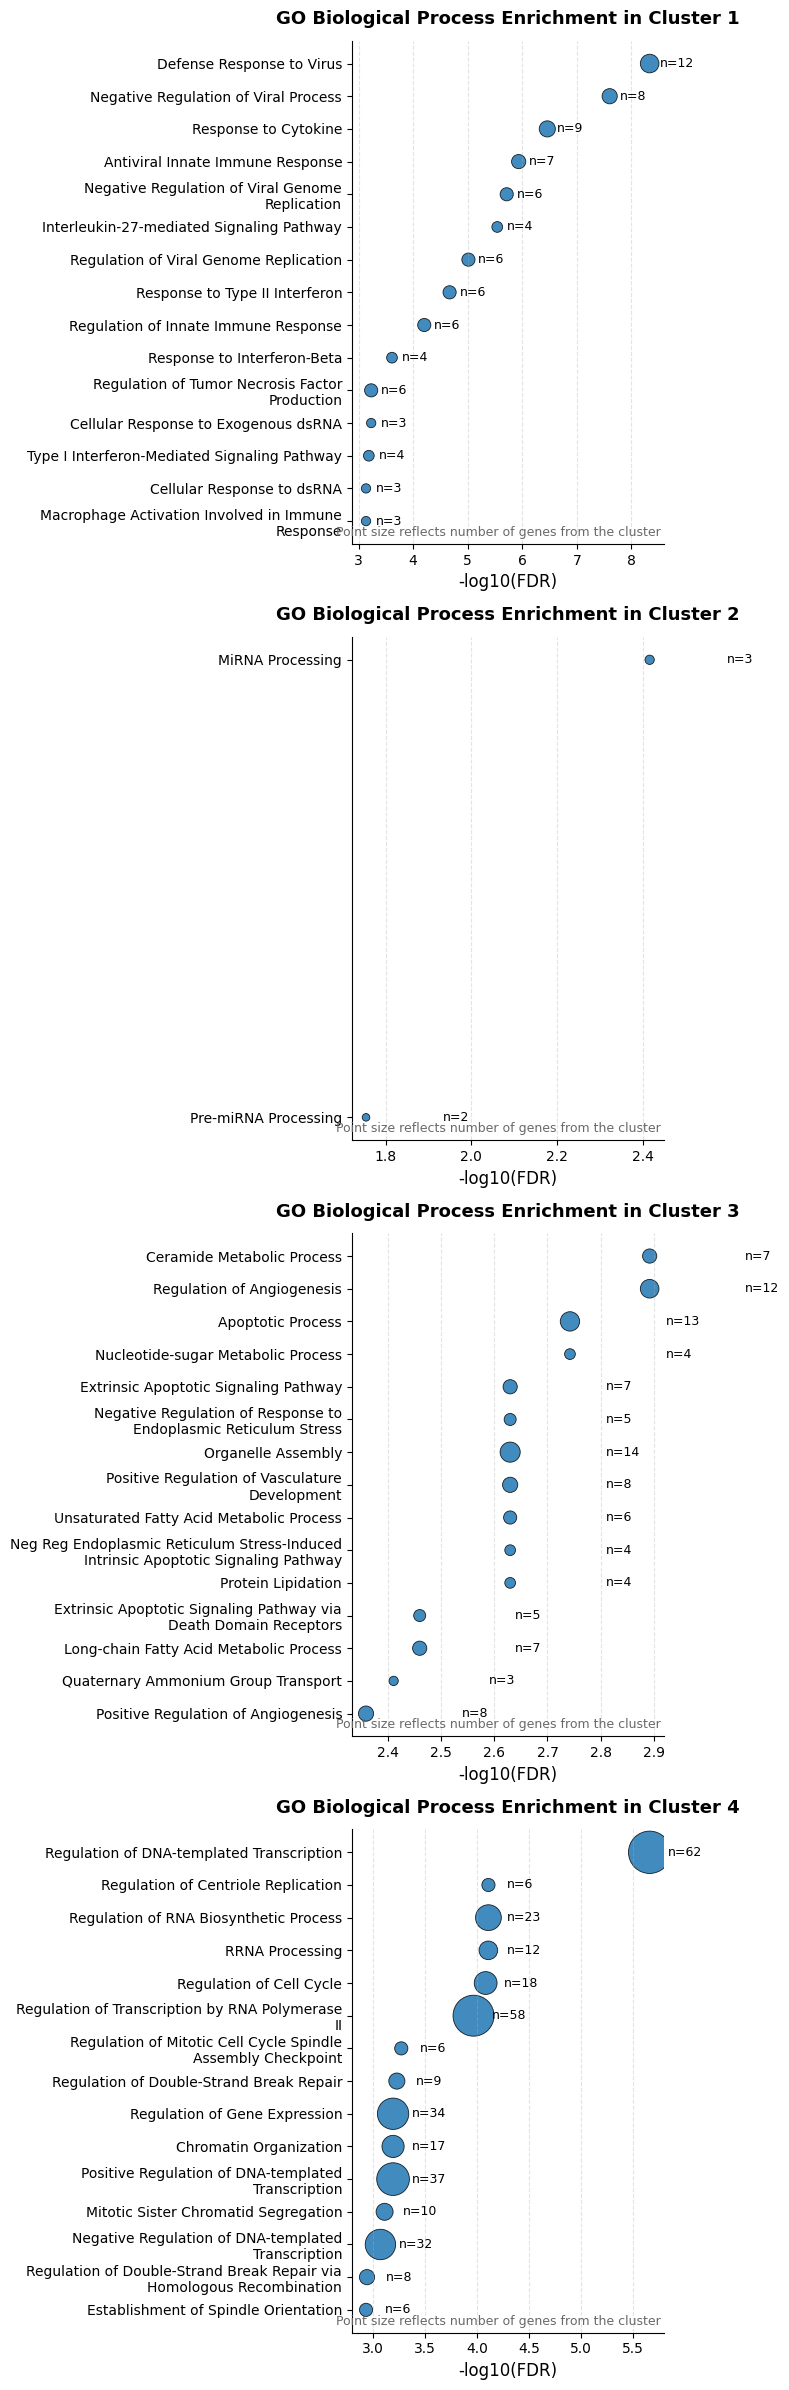

In [ ]:
# DOTPLOT OF SIGNIFICANT GO TERMS

import textwrap
import re

if sig_go.empty:
    print("No significant GO terms to plot.")

else:
    clusters_with_terms = sorted(sig_go["Cluster"].unique())
    fig, axes = plt.subplots(len(clusters_with_terms), 1, figsize=(9, 6 * len(clusters_with_terms)), squeeze=False)

    for ax, cl in zip(axes.flatten(), clusters_with_terms):
        plot_df = sig_go[sig_go["Cluster"] == cl].sort_values("Adjusted P-value").head(15).copy()

        plot_df["minus_log10_FDR"] = -np.log10(plot_df["Adjusted P-value"])
        plot_df["gene_count"] = plot_df["Genes"].fillna("").apply(lambda x: len([g for g in str(x).split(";") if g.strip()]))

        plot_df["Term_clean"] = plot_df["Term"].astype(str).apply(lambda x: re.sub(r"\s*\(GO:\d+\)", "", x))
        plot_df["Term_wrapped"] = plot_df["Term_clean"].apply(lambda x: "\n".join(textwrap.wrap(x, width=45)))

        plot_df = plot_df.iloc[::-1].copy()

        ax.scatter(
            plot_df["minus_log10_FDR"],
            plot_df["Term_wrapped"],
            s=plot_df["gene_count"] * 15,
            alpha=0.85,
            edgecolor="black",
            linewidth=0.6
        )

        for _, row in plot_df.iterrows():
            ax.text(
                row["minus_log10_FDR"] + 0.18,
                row["Term_wrapped"],
                f"n={row['gene_count']}",
                va="center",
                fontsize=9
            )

        ax.set_xlabel("-log10(FDR)", fontsize=12)
        ax.set_ylabel("")
        ax.set_title(f"GO Biological Process Enrichment in Cluster {cl}", fontsize=13, fontweight="bold", pad=12)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(axis="x", linestyle="--", alpha=0.35)
        ax.tick_params(axis="x", labelsize=10)
        ax.tick_params(axis="y", labelsize=10)

        ax.text(
            0.99, 0.01,
            "Point size reflects number of genes from the cluster",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=9,
            color="dimgray"
        )

    plt.tight_layout()
    plt.savefig(f"{prefix}GO_BP_enrichment_dotplot_k{final_k}.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"{prefix}GO_BP_enrichment_dotplot_k{final_k}.pdf", bbox_inches="tight")
    plt.show()

In [ ]:
import re

cluster_order = list(cluster_means.index)

cluster_sizes = (
    clusters["Cluster"]
    .value_counts()
    .sort_index()
    .reindex(cluster_order)
)

def clean_term(term):
    term = str(term)
    term = re.sub(r"\s*\(GO:\d+\)", "", term)
    return term

manual_terms = {
    1: ["Antivirial and interferon response", "Immune response and cytokine signaling"],
    2: ["miRNA processing"],
    3: ["Lipid metabolism", "Apoptosis and cellular stress response", "Angiogenesis and cell migration"],
    4: ["Transcription and RNA processing", "Cell cycle and chromosome segregation", "DNA repair and homologous recombination"],
    5: []
}

landmark_terms = {}
line_counts = {}

for cl in cluster_order:
    top_terms = manual_terms.get(cl, [])

    if top_terms:
        txt = "\n".join(top_terms)
        landmark_terms[cl] = txt
        line_counts[cl] = len(top_terms)
    else:
        landmark_terms[cl] = "—"
        line_counts[cl] = 1

summary_df = pd.DataFrame({
    "Cluster": cluster_order,
    "n_genes": cluster_sizes.values,
    "landmark_terms": [landmark_terms[cl] for cl in cluster_order],
    "n_lines": [line_counts[cl] for cl in cluster_order]
})

display(summary_df)

,Cluster,n_genes,landmark_terms,n_lines
0,1,129,Antivirial and interferon response\nImmune res...,2
1,2,52,miRNA processing,1
2,3,375,Lipid metabolism\nApoptosis and cellular stres...,3
3,4,479,Transcription and RNA processing\nCell cycle a...,3
4,5,515,—,1


/tmp/ipykernel_9571/907736940.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


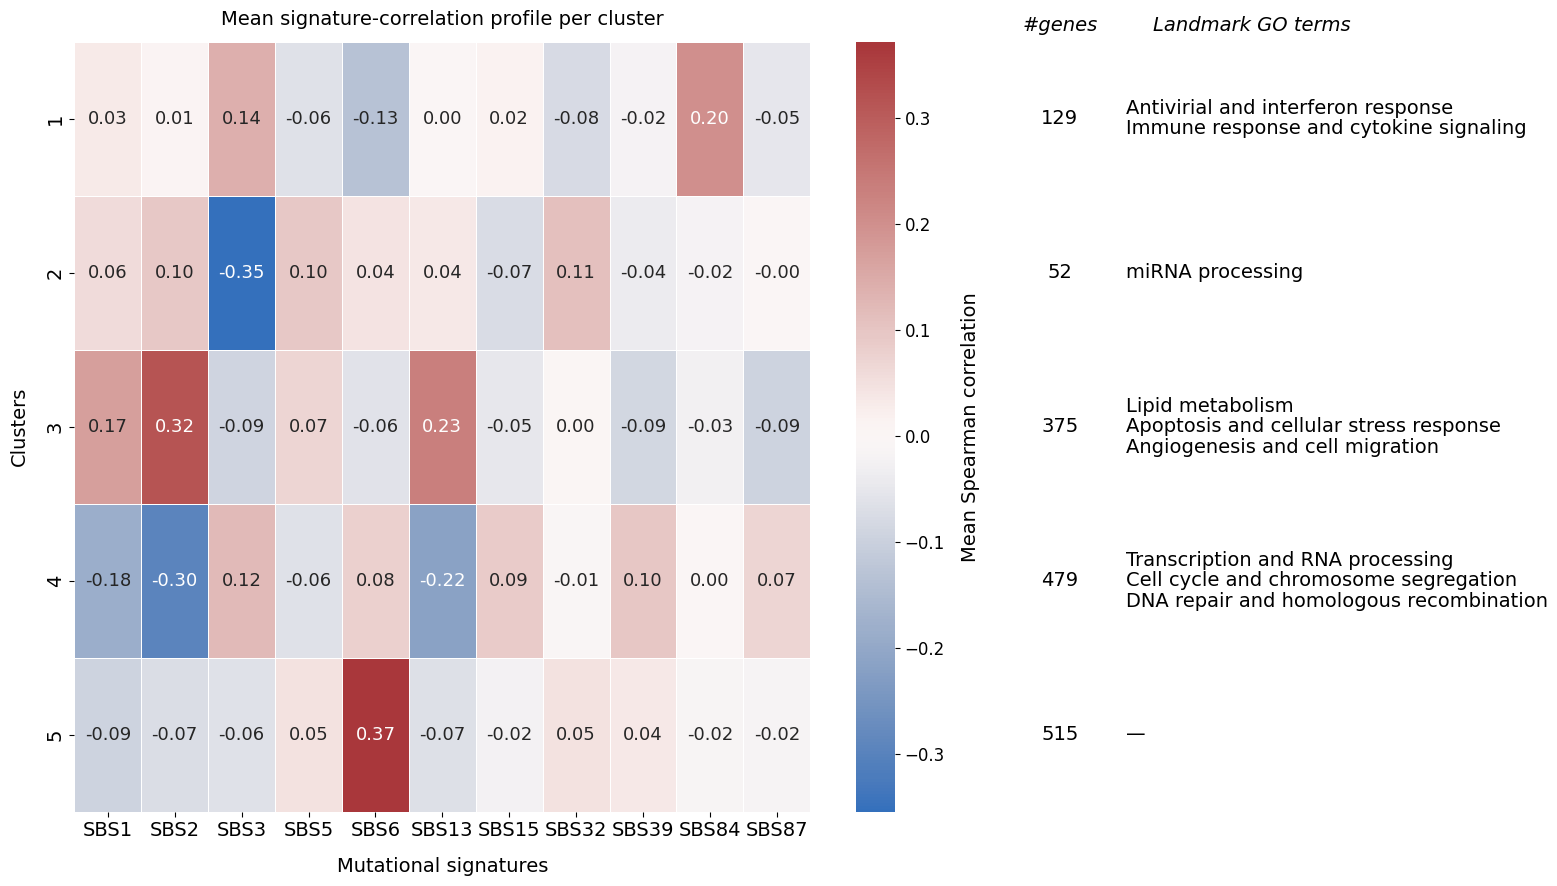

In [ ]:
from matplotlib.gridspec import GridSpec

plot_cluster_means = cluster_means.loc[cluster_order]

base_height = 0.75 * len(cluster_order)
extra_height = 0.18 * summary_df["n_lines"].sum()
fig_height = max(6, base_height + extra_height)

fig = plt.figure(figsize=(17, 10))
gs = GridSpec(1, 3, width_ratios=[10.5, 0.4, 3.2], wspace=0.10)

# Heatmap
ax0 = fig.add_subplot(gs[0, 0])
sns.heatmap(
    plot_cluster_means,
    cmap="vlag",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Mean Spearman correlation"},
    ax=ax0,
    annot_kws={"fontsize": 13.0},
)


cbar = ax0.collections[0].colorbar
cbar.set_label("Mean Spearman correlation", fontsize=14, labelpad=12)
cbar.ax.tick_params(labelsize=12)
ax0.set_title("Mean signature-correlation profile per cluster", pad=12, fontsize=14)
ax0.set_xlabel("Mutational signatures", fontsize=14, labelpad=12)
ax0.set_ylabel("Clusters", fontsize=14, labelpad=12)
ax0.tick_params(axis="x", labelsize=14)
ax0.tick_params(axis="y", labelsize=14)

# Number of genes
ax1 = fig.add_subplot(gs[0, 1])
ax1.set_xlim(0, 1)
ax1.set_ylim(ax0.get_ylim())
ax1.axis("off")
ax1.set_title("#genes", fontstyle="italic", pad=8, x=0.7, fontsize=14)

for i, cl in enumerate(cluster_order):
    ax1.text(
        0.7, i + 0.5,
        str(summary_df.loc[summary_df["Cluster"] == cl, "n_genes"].values[0]),
        ha="center", va="center", fontsize=14
    )

# Landmark GO terms
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_xlim(0, 1)
ax2.set_ylim(ax0.get_ylim())
ax2.axis("off")
ax2.set_title("Landmark GO terms", fontstyle="italic", pad=8, fontsize=14)

for i, cl in enumerate(cluster_order):
    txt = summary_df.loc[summary_df["Cluster"] == cl, "landmark_terms"].values[0]
    ax2.text(
        0.05, i + 0.5,
        txt,
        ha="left",
        va="center",
        fontsize=14.0,
        linespacing=1.1
    )

plt.tight_layout()
plt.savefig(f"{prefix}cluster_summary_GO_k{final_k}.png", dpi=300, bbox_inches="tight")
plt.show()